In [17]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

#carregando o dataset
OASIS_PREPARED_PATH = os.path.join("..", "data", "interim", "oasis_prepared.csv")
def load_oasis_data(path = OASIS_PREPARED_PATH):
    return pd.read_csv(path)

data = load_oasis_data()

#dividindo em X e y
X = data.drop(columns=['Risk.Group'])
y = data['Risk.Group']

print("Dimensões de X: ", X.shape)
print(pd.Series(y).value_counts())

Dimensões de X:  (5150, 7)
Risk.Group
1    2578
0    2572
Name: count, dtype: int64


In [18]:
#fazendo divisão estratificada entre dados de treino e dados de teste pelo train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

#fazendo o preenchimento dos valores nulos dos dados após fazer o Holdout para não haver data leakage
imp = SimpleImputer(missing_values=np.nan, strategy='median')
imp.set_output(transform='pandas')

X_train_imp = imp.fit_transform(X_train)
#aprender e aplicar no treino e apenas aplicar no teste
X_test_imp = imp.transform(X_test)

print(X_train_imp.info())


<class 'pandas.core.frame.DataFrame'>
Index: 3605 entries, 1114 to 1423
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         3605 non-null   float64
 1   EDUC        3605 non-null   float64
 2   SES         3605 non-null   float64
 3   MMSE        3605 non-null   float64
 4   eTIV        3605 non-null   float64
 5   nWBV        3605 non-null   float64
 6   Gender.Num  3605 non-null   float64
dtypes: float64(7)
memory usage: 225.3 KB
None


In [19]:
#fazendo a normalização dos dados após fazer o Holdout para não haver data leakage
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

#usando os modelos de AM que a prof mariana usou no laboratório para começar a mexer com os dados

#Treinamento 1: KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

#Treinamento 2: Árvore de Decisão
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print('Métricas KNN:')
print(f"Accuracy: {accuracy_score(y_test,y_pred_knn):.4f} | Precision: {precision_score(y_test, y_pred_knn):.4f} | Recall: {recall_score(y_test, y_pred_knn):.4f} | F1: {f1_score(y_test, y_pred_knn):.4f}")
print('Métricas Árvore de Decisão:')
print(f"Accuracy: {accuracy_score(y_test,y_pred_dt):.4f} | Precision: {precision_score(y_test, y_pred_dt):.4f} | Recall: {recall_score(y_test, y_pred_dt):.4f} | F1: {f1_score(y_test, y_pred_dt):.4f}")

Métricas KNN:
Accuracy: 0.8168 | Precision: 0.8571 | Recall: 0.7607 | F1: 0.8060
Métricas Árvore de Decisão:
Accuracy: 0.7676 | Precision: 0.7634 | Recall: 0.7762 | F1: 0.7697


As métricas do KNN estão um pouco melhores que as da arvore de decisão. 

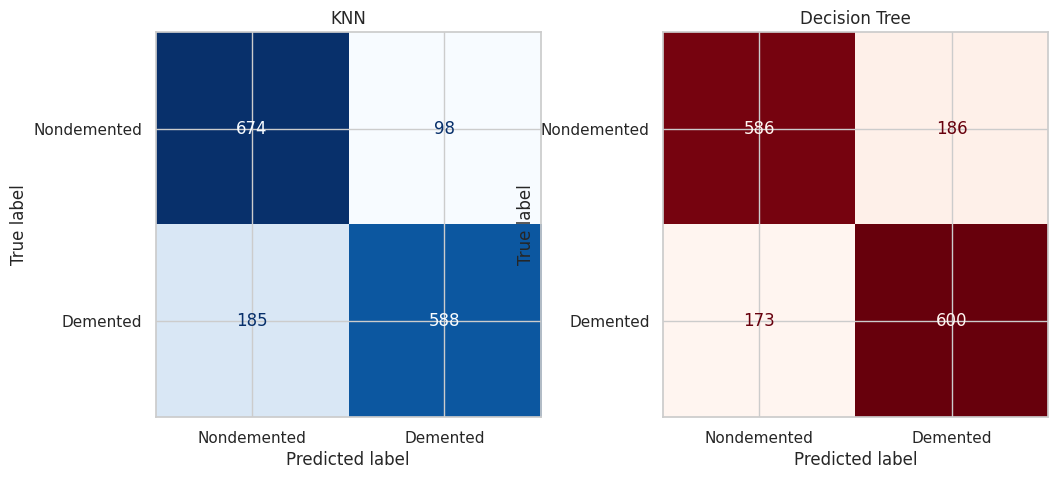

In [20]:
#criando matrizes de confusão
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn, display_labels=['Nondemented', 'Demented'], cmap='Blues', colorbar=False, ax=ax[0])
ax[0].set_title("KNN")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt, display_labels=['Nondemented', 'Demented'], cmap='Reds', colorbar=False, ax=ax[1])
ax[1].set_title("Decision Tree")
plt.show()

Dentre esses modelos, o melhor modelo para identificar a classe "Demented" é o Decision Tree. Isso é importante, pois precisamos deixar passar o mínimo possível de Falsos Negativos (focar em não dizer que alguém que TEM chance de ter Alzheimer NÃO tem chance de ter Alzheimer): foco na métrica "Recall". Mas ainda assim as métricas estão ruins.

In [21]:
#checando o overfitting

y_pred_knn_train = knn.predict(X_train_scaled)
accuracy_knn_train = accuracy_score(y_train, y_pred_knn_train)
accuracy_knn_test = accuracy_score(y_test, y_pred_knn)
print(f"KNN Train Accuracy: {accuracy_knn_train:.4f} | KNN Test Accuracy: {accuracy_knn_test:.4f}")

y_pred_dt_train = dt.predict(X_train_scaled)
accuracy_dt_train = accuracy_score(y_train, y_pred_dt_train)
accuracy_dt_test = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Train Accuracy: {accuracy_dt_train:.4f} | Decision Tree Test Accuracy: {accuracy_dt_test:.4f}")

KNN Train Accuracy: 0.8760 | KNN Test Accuracy: 0.8168
Decision Tree Train Accuracy: 1.0000 | Decision Tree Test Accuracy: 0.7676


Comparando as acurácias do treino e do teste, parece que a decision tree está com overfitting. Como melhorar? Teste: definir profundidade máxima e quantidade mínima de pacientes por folha.

In [37]:
#novo treinamento para diminuir overfitting

#Treinamento 2: Árvore de Decisão
dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print('Métricas Árvore de Decisão:')
print(f"Accuracy: {accuracy_score(y_test,y_pred_dt):.4f} | Precision: {precision_score(y_test, y_pred_dt):.4f} | Recall: {recall_score(y_test, y_pred_dt):.4f} | F1: {f1_score(y_test, y_pred_dt):.4f}")

#checando o overfitting

y_pred_dt_train = dt.predict(X_train_scaled)
accuracy_dt_train = accuracy_score(y_train, y_pred_dt_train)
accuracy_dt_test = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Train Accuracy: {accuracy_dt_train:.4f} | Decision Tree Test Accuracy: {accuracy_dt_test:.4f}")

Métricas Árvore de Decisão:
Accuracy: 0.8201 | Precision: 0.9188 | Recall: 0.7025 | F1: 0.7962
Decision Tree Train Accuracy: 0.8402 | Decision Tree Test Accuracy: 0.8201


A partir desses novos valores, parece não haver mais tanto overfitting. No entanto, o recall está bem ruim.

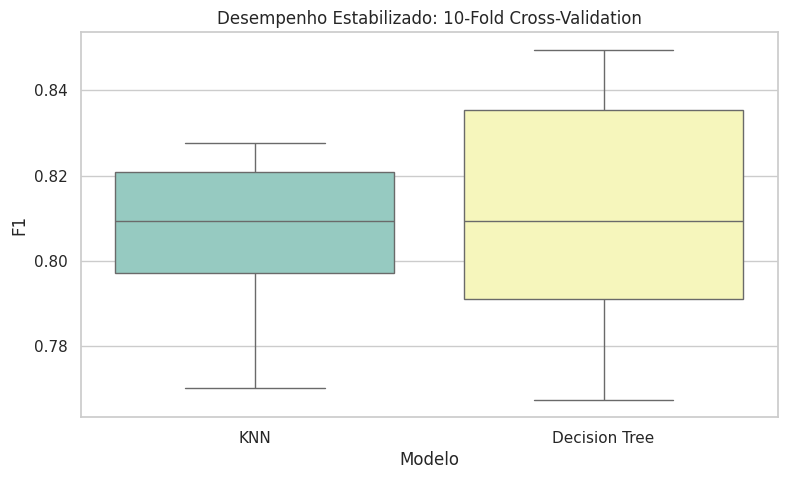

In [23]:
#fazendo o cross validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring_dict = {'acuracia':'accuracy', 'precisao':'precision', 'recall':'recall', 'f1':'f1'}

#envolvendo simple imputer + scaling + classificador no pipeline

pipe_knn = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])
pipe_dt = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', MinMaxScaler()),
    ('dt', DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42))
])

cv_knn = cross_validate(pipe_knn, X_train, y_train, cv=cv, scoring=scoring_dict)
cv_dt = cross_validate(pipe_dt, X_train, y_train, cv=cv, scoring=scoring_dict)

res_df = pd.DataFrame({
    'Modelo': ['KNN']*10 + ['Decision Tree']*10,
    'F1': list(cv_knn['test_f1']) + list(cv_dt['test_f1'])
})

plt.figure(figsize=(9, 5))
sns.boxplot(data=res_df, x='Modelo', y='F1', hue='Modelo', palette='Set3', legend=False)
plt.title("Desempenho Estabilizado: 10-Fold Cross-Validation")
plt.show()

A partir deste gráfico, podemos ver que a mediana do f1 para os dois modelos está muito parecida, mas o knn está muito mais estabilizado

In [38]:
#variação do F1 no knn para os 10 folds
cv_knn['test_f1']

array([0.8125    , 0.82285714, 0.79532164, 0.80597015, 0.80232558,
       0.77058824, 0.82738095, 0.82758621, 0.81437126, 0.77014925])

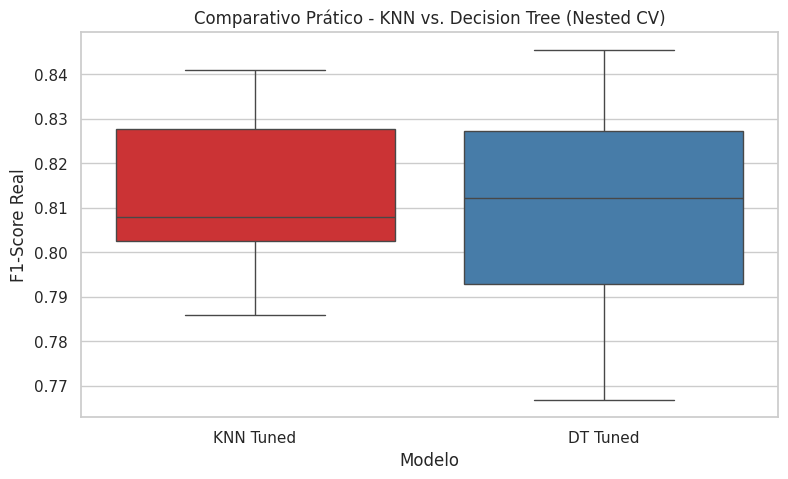

In [25]:
#fazendo otimização de hiperparâmetros com nested cross validation

param_grid_knn = {
    'knn__n_neighbors': [1, 3, 5, 7, 11, 13, 15],
    'knn__weights': ['uniform', 'distance']
}

param_grid_dt = {
    'dt__max_depth': [None, 4, 5, 10],
    'dt__min_samples_split': [2, 5, 10]
}

grid_knn = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='f1')
res_knn_nested = cross_validate(grid_knn, X_train, y_train, cv=cv, scoring=scoring_dict)

grid_dt = GridSearchCV(pipe_dt, param_grid_dt, cv=5, scoring='f1', refit=True)
res_dt_nested = cross_validate(grid_dt, X_train, y_train, cv=cv, scoring=scoring_dict)

comp_df = pd.DataFrame({
    'Modelo': ['KNN Tuned']*10 + ['DT Tuned']*10,
    'F1-Score Real': list(res_knn_nested['test_f1']) + list(res_dt_nested['test_f1'])
})

plt.figure(figsize=(9, 5))
sns.boxplot(data=comp_df, x='Modelo', y='F1-Score Real', palette='Set1',hue='Modelo', legend= False)
plt.title("Comparativo Prático - KNN vs. Decision Tree (Nested CV)")
plt.show()

A partir da comparação entre os diferentes modelos usando o Nested Cross Validation, podemos ver que a mediana do knn está mais baixa, mas o knn está com resultados bem mais estáveis que a decision tree.

In [39]:
#após o Nested CV nos convencer de que o knn é o mais adequado, vamos pegar os melhores parâmetros
final_grid = GridSearchCV(pipe_knn, param_grid_knn, cv=5, scoring='f1')
final_grid.fit(X_train, y_train)
print(final_grid.best_params_)

{'knn__n_neighbors': 7, 'knn__weights': 'uniform'}


              precision    recall  f1-score   support

           0       0.78      0.88      0.83       772
           1       0.87      0.76      0.81       773

    accuracy                           0.82      1545
   macro avg       0.83      0.82      0.82      1545
weighted avg       0.83      0.82      0.82      1545



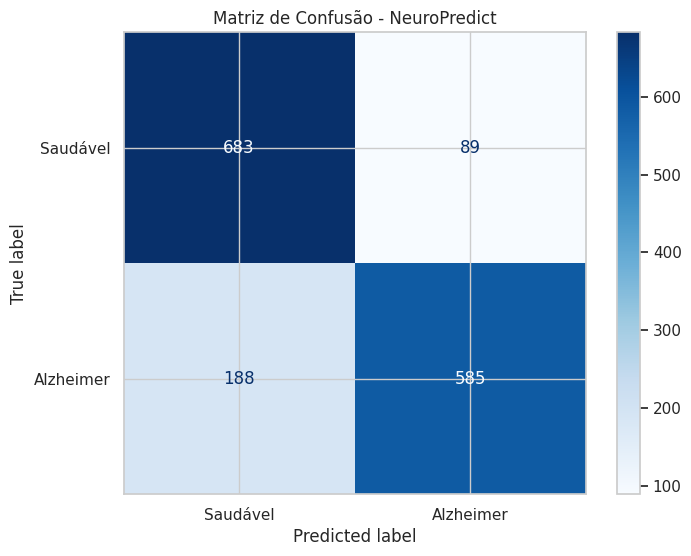

In [40]:
#utilizando o melhor modelo para extrair as predições para os dados de teste

#classes preditas
y_pred = final_grid.predict(X_test)
#probabilidade de ser 1
y_pred_prob = final_grid.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=['Saudável', 'Alzheimer'], 
    cmap='Blues', 
    ax=ax
)
plt.title('Matriz de Confusão - NeuroPredict')
plt.show()

In [41]:
import pandas as pd

# 1. Criar um DataFrame de resultados
df_resultados = pd.DataFrame({
    'Realidade': y_test.values,
    'Predição': y_pred,
    'Probabilidade_Alzheimer': y_pred_prob
})

# 2. Mostrar as primeiras linhas
print("Visualização das Predições e Probabilidades:")
display(df_resultados.head(20))

Visualização das Predições e Probabilidades:


,Realidade,Predição,Probabilidade_Alzheimer
0,1,1,1.000000
1,1,1,1.000000
2,1,1,1.000000
3,0,0,0.428571
4,1,1,1.000000
5,1,1,1.000000
6,1,1,0.857143
7,1,1,0.857143
8,0,0,0.000000
9,0,0,0.142857
